In [169]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics


import tensorflow as tf
import keras
from keras import layers

In [170]:
df = pd.read_csv("housing.csv")

In [171]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [172]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


#### For further analysis I will create a new column "distance_to_nearest_city" using haversine and I will drop lon and lat. Geographical coordinates are not good for machine learning to use, they can create problems. 

In [173]:
# here I will create a new feature "distance_to_nearest_city" based on longitude and latitude
# approximate coordinates of 2 biggerst cities:
sf_coords = (37.7749, -122.4194)  # San Francisco
la_coords = (34.0522, -118.2437)  # Los Angeles

In [174]:
# Use haversine formula (distance in km):

from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [175]:
# Create a column for the shortest distance:

df['distance_to_nearest_city'] = df.apply(
    lambda row: round(min(
        haversine(row['latitude'], row['longitude'], *sf_coords),
        haversine(row['latitude'], row['longitude'], *la_coords)
    ), 2),
    axis=1
)
# ChatGPT helped me to calculate the distance using haversine formula

In [176]:
# now i will drop lon and lat
df = df.drop(columns=['latitude', 'longitude'])
df.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,distance_to_nearest_city
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,20.33
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,19.91
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,17.84
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,17.06
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,17.06


In [177]:
# "ocean_proximity" is nominal categorical variable, I will use one-hot encoding to convert it to numerical
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [178]:
# to use dataset in ydata-profiling, I will save it without encoded variables:
df.to_csv("housing_for_ydata_report.csv", index=False)

In [179]:
# by using encoder we will add 5 new columns, but will remove one -  and the original one.
from sklearn.preprocessing import OneHotEncoder
variables = ['ocean_proximity']

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [180]:
df.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,20.33,0,0,0,1,0
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,19.91,0,0,0,1,0
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,17.84,0,0,0,1,0
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,17.06,0,0,0,1,0
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,17.06,0,0,0,1,0


In [181]:
# dropping the last variable:
df = df.drop("ocean_proximity_NEAR OCEAN", axis=1)

In [182]:
# checking missing values
df.isnull().sum()

housing_median_age             0
total_rooms                    0
total_bedrooms               207
population                     0
households                     0
median_income                  0
median_house_value             0
distance_to_nearest_city       0
ocean_proximity_<1H OCEAN      0
ocean_proximity_INLAND         0
ocean_proximity_ISLAND         0
ocean_proximity_NEAR BAY       0
dtype: int64

In [183]:
# drop rows with missing values
df = df.dropna()

In [184]:
# check
df.isnull().sum()

housing_median_age           0
total_rooms                  0
total_bedrooms               0
population                   0
households                   0
median_income                0
median_house_value           0
distance_to_nearest_city     0
ocean_proximity_<1H OCEAN    0
ocean_proximity_INLAND       0
ocean_proximity_ISLAND       0
ocean_proximity_NEAR BAY     0
dtype: int64

In [185]:
# to use this dataset in other tools I will create a new csv file. This dataset will be without longitude and latitude.
df.to_csv("housing_modified.csv", index=False)

In [186]:
df = pd.read_csv("housing_modified.csv")
df.head()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,distance_to_nearest_city,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY
0,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,20.33,0,0,0,1
1,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,19.91,0,0,0,1
2,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,17.84,0,0,0,1
3,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,17.06,0,0,0,1
4,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,17.06,0,0,0,1


In [187]:
df.columns

Index(['housing_median_age', 'total_rooms', 'total_bedrooms', 'population',
       'households', 'median_income', 'median_house_value',
       'distance_to_nearest_city', 'ocean_proximity_<1H OCEAN',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY'],
      dtype='object')

#### X/y -split + VIF -test for multicollinearity

In [188]:

 # use everything else except, the target
X = df.drop("median_house_value", axis=1)

# our target variable is y
y = df['median_house_value']

In [189]:
# Finding columns with potential multicollinearity (VIF-test)
# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 

# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 
  

# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, confusing the logistic regression
print(vif_data)

                      feature        VIF
0          housing_median_age   4.872786
1                 total_rooms  28.925871
2              total_bedrooms  89.585178
3                  population  16.237567
4                  households  92.983346
5               median_income   5.973328
6    distance_to_nearest_city   2.668838
7   ocean_proximity_<1H OCEAN   3.762455
8      ocean_proximity_INLAND   2.865675
9      ocean_proximity_ISLAND   1.002532
10   ocean_proximity_NEAR BAY   1.883777


<Axes: >

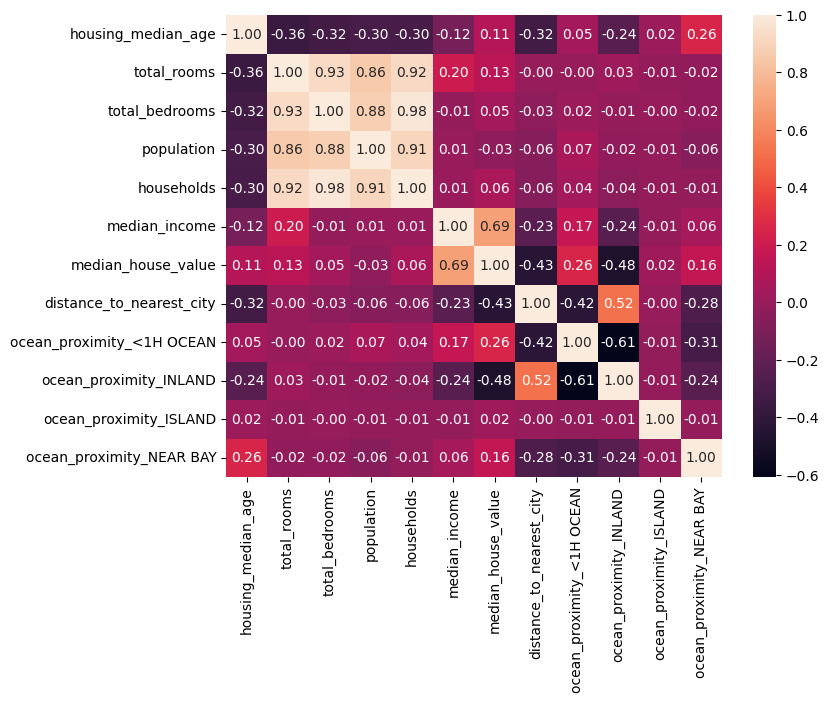

In [190]:
# correlation matrix 
plt.figure(figsize=(8, 6))

correlations = df.corr(numeric_only=True)
sns.heatmap(correlations, annot=True, fmt='.2f')